In [2]:
import pandas as pd
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [5]:
df.pivot_table(index='job_title_short',aggfunc='size')

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [6]:
df.groupby('job_title_short').size()

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [10]:
df.pivot_table(index='job_title_short', values ='salary_year_avg',columns='job_country',aggfunc='median')

job_country,Albania,Algeria,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Bangladesh,Belarus,...,Uganda,Ukraine,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Vietnam,Zambia,Zimbabwe
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,NaN,NaN,71100.00,NaN,70000.0,NaN,NaN,NaN,16500.0,NaN,...,NaN,72900.0,NaN,56700.0,90000.0,NaN,NaN,79200.0,NaN,NaN
Cloud Engineer,NaN,NaN,197500.00,NaN,110000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,89100.0,NaN,NaN,116100.0,NaN,NaN,NaN,NaN,NaN
Data Analyst,49950.00,44100.0,92771.75,100500.0,109500.0,80850.00,NaN,NaN,NaN,400000.0,...,69300.0,72900.0,98500.0,87750.0,90000.0,100500.0,NaN,75550.0,NaN,63000.0
Data Engineer,NaN,45000.0,96773.00,48750.0,106712.5,147500.00,NaN,211000.0,97444.0,NaN,...,NaN,89100.0,97528.0,110000.0,125000.0,NaN,NaN,96773.0,NaN,NaN
Data Scientist,69981.25,NaN,71000.00,NaN,139216.0,71249.75,NaN,NaN,NaN,NaN,...,84200.0,131846.5,166419.5,105300.0,130000.0,NaN,30750.0,70000.0,90670.0,69085.0
Machine Learning Engineer,NaN,NaN,101029.00,87021.0,101029.0,89100.00,NaN,228750.0,69000.0,NaN,...,NaN,89100.0,62850.0,149653.0,150000.0,50000.0,NaN,57600.0,NaN,NaN
Senior Data Analyst,NaN,NaN,NaN,NaN,50640.0,89100.00,NaN,NaN,NaN,NaN,...,NaN,NaN,105837.5,111175.0,110000.0,NaN,NaN,105837.5,NaN,NaN
Senior Data Engineer,NaN,NaN,147500.00,NaN,147500.0,147500.00,NaN,173500.0,NaN,NaN,...,NaN,96773.0,NaN,147500.0,150000.0,NaN,NaN,147500.0,NaN,NaN
Senior Data Scientist,157500.00,NaN,NaN,NaN,157500.0,80850.00,NaN,NaN,NaN,NaN,...,NaN,157500.0,72000.0,157500.0,155000.0,57500.0,NaN,79200.0,NaN,NaN


In [11]:
df.pivot_table(index='job_country', values ='salary_year_avg',columns='job_title_short',aggfunc='median')

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


In [26]:
top_countries=df['job_country'].value_counts().head(6).index
print(top_countries)

top1_countries=df['job_country'].size
print(top1_countries)

df_job_country_salary= df.pivot_table(
    index='job_country',
    values ='salary_year_avg',
    columns='job_title_short',
    aggfunc='median')

df_job_country_salary=df_job_country_salary.loc[top_countries]



job_titles=['Data Analyst',	'Data Engineer','Data Scientist']

df_job_country_salary=df_job_country_salary[job_titles]


df_job_country_salary

Index(['United States', 'India', 'United Kingdom', 'France', 'Germany',
       'Spain'],
      dtype='object', name='job_country')
785741


job_title_short,Data Analyst,Data Engineer,Data Scientist
job_country,,,
United States,90000.0,125000.0,130000.0
India,100500.0,147500.0,114008.0
United Kingdom,87750.0,110000.0,105300.0
France,69175.0,98301.5,88128.0
Germany,103750.0,147500.0,131560.0
Spain,91977.0,133000.0,88128.0


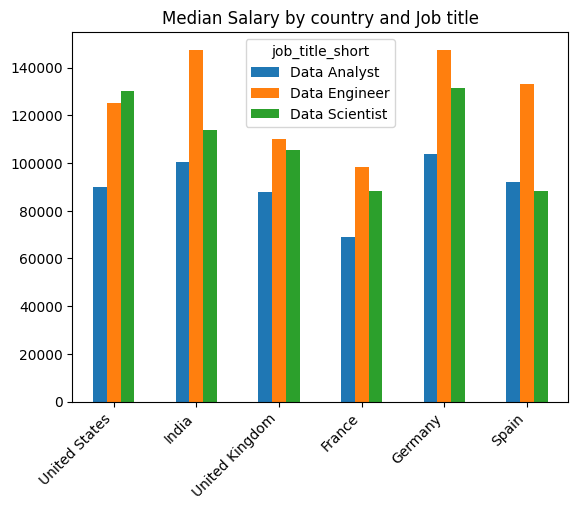

In [40]:
df_job_country_salary.plot(kind='bar')

plt.xticks(rotation=45,ha='right')
plt.xlabel('')
plt.title('Median Salary by country and Job title')
plt.show()

<span style = " color:green;font-width:bold; font-size:32px;"> Practise Prompts </span>

In [54]:
# Problem Statement:
# Create a pivot table to count the number of job postings for each job_title_short and job_country. 
# Display the first 10 rows of the resulting pivot table.
 
df.info()

job_country= df.pivot_table(columns='job_title_short', index='job_country' , aggfunc='size')


job_country.head(10)

print('******')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [66]:
# Problem Statement:
# Create a pivot table to find the maximum, minimum, and average salary_year_avg for each company_name.
# Display the first 5 rows of the resulting pivot table. 


job_country_agg= df.pivot_table(index='company_name' ,
                                values= 'salary_year_avg',
                                aggfunc= ['min','max','median'])



print(job_country_agg.head(10))

print('******')


                                    min             max          median
                        salary_year_avg salary_year_avg salary_year_avg
company_name                                                           
#twiceasnice Recruiting    61000.000000   120000.000000    65000.000000
/dev/color                125000.000000   125000.000000   125000.000000
0nward Select              92500.000000    92500.000000    92500.000000
1 Point System            137290.484375   137290.484375   137290.484375
1 Point System LLC.       170000.000000   170000.000000   170000.000000
1-800-FLOWERS.COM, INC.   190000.000000   190000.000000   190000.000000
100Insure                  97500.000000    97500.000000    97500.000000
10x Genomics              155000.000000   155000.000000   155000.000000
16 Points Holdings LLC     50000.000000    50000.000000    50000.000000
1872 Consulting           137500.000000   147500.000000   145000.000000
******


In [71]:
# Problem Statement:
# Create a pivot table to calculate the median of salary_year_avg for each company_name and job_country:

# Filter the pivot table to only include 'Data Scientist' roles.
# Then filter the pivot table to only include company_name with a median salary_year_avg greater than 200,000.
# Display the first 10 rows of the resulting pivot table.

df_ds=df.copy()
df_ds=df_ds[df_ds['job_title_short']=='Data Scientist']

pivot_table=df_ds.pivot_table(index=['company_name' ,'job_country'],
                              values= 'salary_year_avg',
                              aggfunc= 'median')

pivot_table

pivot_table=pivot_table[pivot_table['salary_year_avg'] > 200000]

pivot_table


salary_year_avg
company_name job_country                   
ACT          Sudan                 225000.0
             United States         225000.0
Abbott       United States         204000.0
Airbnb       United States         212500.0
Airtable     Sudan                 215500.0
...                                     ...
Zocdoc       United States         208500.0
Zoox         United States         255000.0
Zoox.com     United States         350000.0
expand group United States         265000.0
nitruc       United States         255000.0

[175 rows x 1 columns]